# Install Required Libraries

In [2]:
pip install prophet scikit-learn pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


# Data Loading and Aggregation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the uploaded dataset
df = pd.read_csv('walmart cleaned data.csv')

# Convert Date column to a standard datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Filter for a single high-volume time series
sub_df = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy()

# Sort chronologically
sub_df = sub_df.sort_values('Date')

# Inspect the shape and columns
print(f"Dataset shape for Store 1, Dept 1: {sub_df.shape}")
sub_df.head()

Dataset shape for Store 1, Dept 1: (143, 17)


,Unnamed: 0,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,0,1,2010-02-05,0,1,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315
137,137,1,2010-02-12,1,1,46039.49,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,3,151315
192,192,1,2010-02-19,0,1,41595.55,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,3,151315
273,273,1,2010-02-26,0,1,19403.54,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,3,151315
313,313,1,2010-03-05,0,1,21827.90,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,3,151315


# Visualizing the Demand Trend

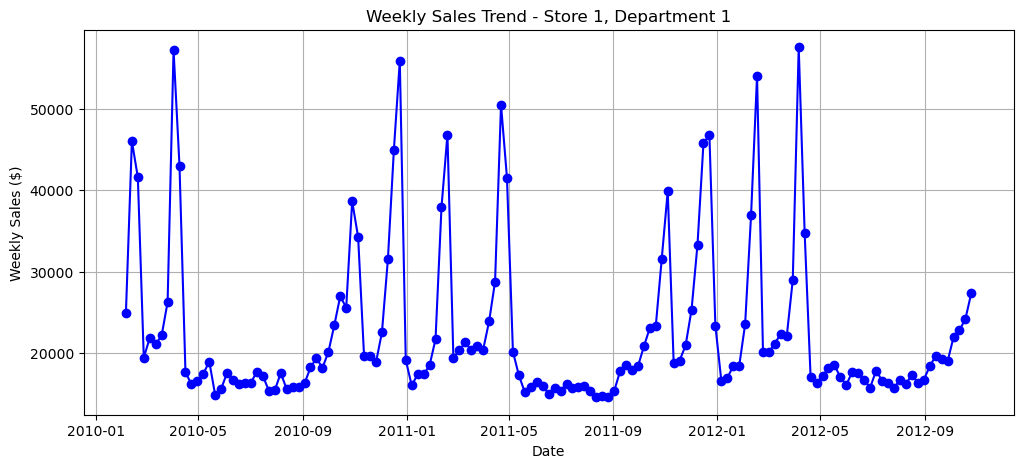

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(sub_df['Date'], sub_df['Weekly_Sales'], marker='o', color='b', linestyle='-')
plt.title('Weekly Sales Trend - Store 1, Department 1')
plt.xlabel('Date')
plt.ylabel('Weekly Sales ($)')
plt.grid(True)
plt.show()

# Structuring Data for Prophet

In [8]:
# Select core columns and rename for Prophet compatibility
prophet_df = sub_df[['Date', 'Weekly_Sales', 'IsHoliday', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].copy()
prophet_df.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'}, inplace=True)

# Prophet works best with explicit float formats for regressors
regressors = ['IsHoliday', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
for col in regressors:
    prophet_df[col] = prophet_df[col].astype(float)

# Split into Train and Test sets (Hold out the last 12 weeks for evaluation)
train_size = len(prophet_df) - 12
train_data = prophet_df.iloc[:train_size]
test_data = prophet_df.iloc[train_size:]

print(f"Training rows: {len(train_data)} | Testing rows: {len(test_data)}")

Training rows: 131 | Testing rows: 12


# Initialize, Configure, and Train the Model

In [7]:
from prophet import Prophet

# 1. Initialize Prophet with yearly and weekly seasonalities enabled
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)

# 2. Add promotions and holidays as exogenous features
for col in regressors:
    model.add_regressor(col)

# 3. Fit the model on the training subset
model.fit(train_data)
print("Model training complete!")

13:28:40 - cmdstanpy - INFO - Chain [1] start processing
13:28:40 - cmdstanpy - INFO - Chain [1] done processing


Model training complete!


# Generate Predictions (Forecast)

In [9]:
# Extract the test period features (dates + promotions)
future_df = test_data[['ds'] + regressors].copy()

# Predict the demand
forecast = model.predict(future_df)

# Extract predictions alongside the actual test results
evaluation_df = test_data[['ds', 'y']].merge(forecast[['ds', 'yhat']], on='ds')
evaluation_df.rename(columns={'y': 'Actual_Sales', 'yhat': 'Forecasted_Sales'}, inplace=True)
evaluation_df

,ds,Actual_Sales,Forecasted_Sales
0,2012-08-10,16119.92,15360.188197
1,2012-08-17,17330.70,15632.787343
2,2012-08-24,16286.40,15231.632332
3,2012-08-31,16680.24,16287.088916
4,2012-09-07,18322.37,15764.572283
5,2012-09-14,19616.22,18699.725462
6,2012-09-21,19251.50,19713.226950
7,2012-09-28,18947.81,19640.660640
8,2012-10-05,21904.47,19643.188112
9,2012-10-12,22764.01,21487.723939


# Evaluate with RMSE and MAPE

In [10]:
from sklearn.metrics import mean_squared_error

actuals = evaluation_df['Actual_Sales'].values
predictions = evaluation_df['Forecasted_Sales'].values

# Calculate Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(actuals, predictions))

# Calculate Mean Absolute Percentage Error
mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

print("--- EVALUATION METRICS ---")
print(f"RMSE (Root Mean Squared Error): ${rmse:.2f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
print(f"Model Accuracy: {100 - mape:.2f}%")

--- EVALUATION METRICS ---
RMSE (Root Mean Squared Error): $2396.39
MAPE (Mean Absolute Percentage Error): 8.38%
Model Accuracy: 91.62%


# Visualize the Forecast Accuracy

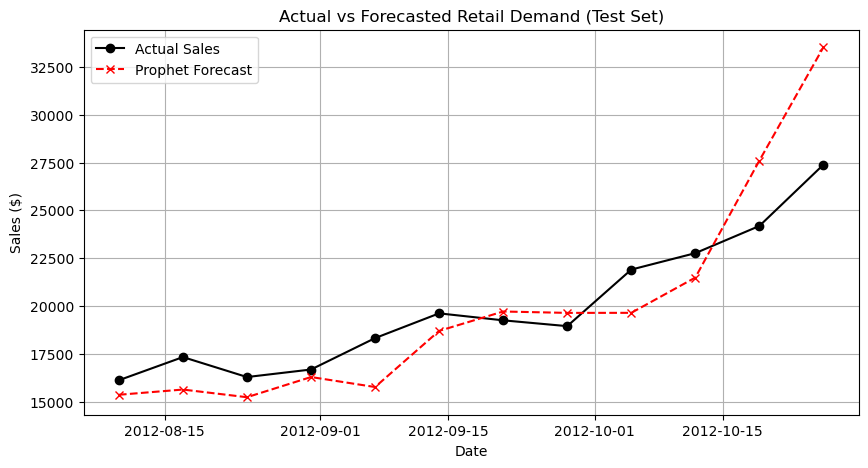

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(evaluation_df['ds'], evaluation_df['Actual_Sales'], label='Actual Sales', marker='o', color='black')
plt.plot(evaluation_df['ds'], evaluation_df['Forecasted_Sales'], label='Prophet Forecast', marker='x', linestyle='--', color='red')
plt.title('Actual vs Forecasted Retail Demand (Test Set)')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True)
plt.show()